New names:
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`


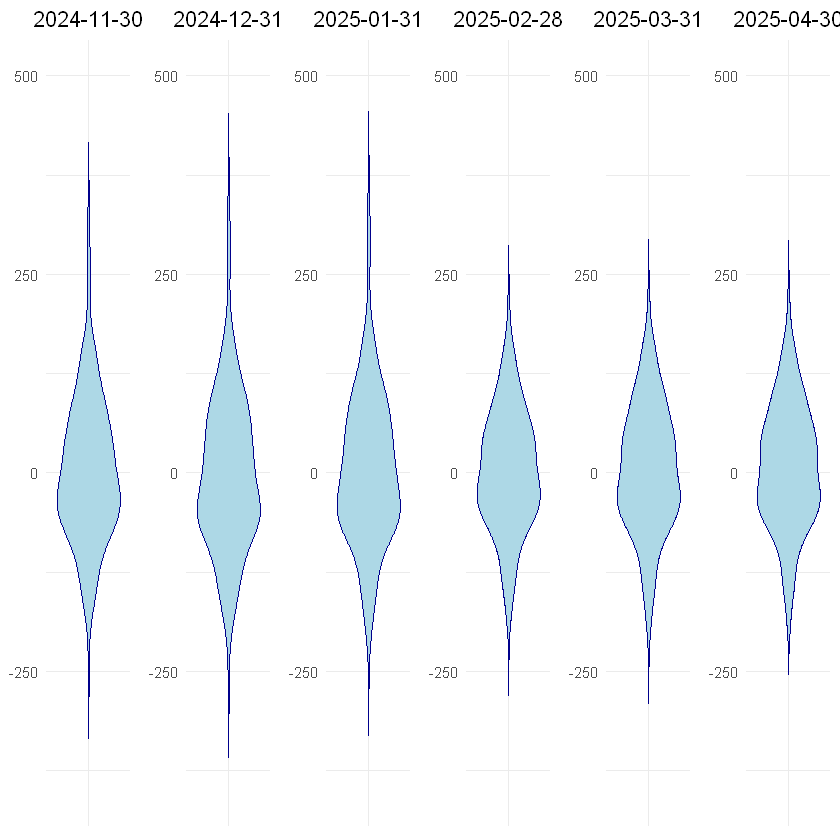

In [11]:
library(readxl)
library(ggplot2)
library(dplyr)
library(gridExtra)

# Load the data from the Excel file
file_path <- "Nov_to_Apr_violins.xlsx"
data <- read_excel(file_path)

# Select relevant columns and remove rows with NA in critical columns only
selected_data <- data %>%
  select(Month_End, PnL_Distribution) %>%
  filter(!is.na(Month_End) & !is.na(PnL_Distribution))

# Convert Month_End to Date for proper chronological ordering
selected_data$Month_End <- as.Date(selected_data$Month_End)

# Sort month levels chronologically (oldest first)
month_levels <- sort(unique(selected_data$Month_End))

# Generate violin plots with fixed y-axis limits (-400 to 600)
violin_plots <- lapply(month_levels, function(month) {
  ggplot(filter(selected_data, Month_End == month), aes(x = factor(1), y = PnL_Distribution)) +
    geom_violin(trim = FALSE, fill = "lightblue", color = "darkblue") +
    labs(title = as.character(month), x = NULL, y = NULL) +
    ylim(-400, 500) +
    theme_minimal() +
    theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(),
          plot.title = element_text(hjust = 0.5))
})

# Arrange all plots in one row (ascending chronological order)
grid.arrange(grobs = violin_plots, ncol = length(month_levels))


New names:
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`


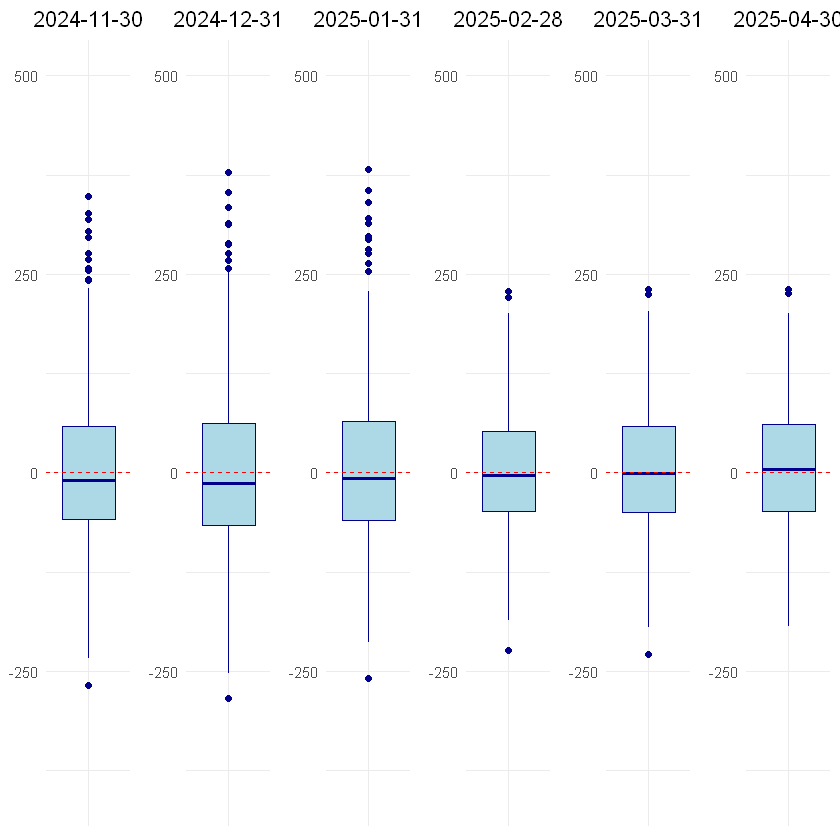

In [12]:
library(readxl)
library(ggplot2)
library(dplyr)
library(gridExtra)

# Load the data from the Excel file
file_path <- "Nov_to_Apr_violins.xlsx"
data <- read_excel(file_path)

# Select relevant columns and remove rows with NA in critical columns only
selected_data <- data %>%
  select(Month_End, PnL_Distribution) %>%
  filter(!is.na(Month_End) & !is.na(PnL_Distribution))

# Convert Month_End to Date for proper chronological ordering
selected_data$Month_End <- as.Date(selected_data$Month_End)

# Sort month levels chronologically (oldest first)
month_levels <- sort(unique(selected_data$Month_End))

# Generate boxplots with fixed y-axis limits (-400 to 500) and zero line
box_plots <- lapply(month_levels, function(month) {
  ggplot(filter(selected_data, Month_End == month), aes(x = factor(1), y = PnL_Distribution)) +
    geom_boxplot(fill = "lightblue", color = "darkblue") +
    geom_hline(yintercept = 0, color = "red", linetype = "dashed") +  # zero line
    labs(title = as.character(month), x = NULL, y = NULL) +
    ylim(-400, 500) +
    theme_minimal() +
    theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(),
          plot.title = element_text(hjust = 0.5))
})

# Arrange all plots in one row (ascending chronological order)
grid.arrange(grobs = box_plots, ncol = length(month_levels))


New names:
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`


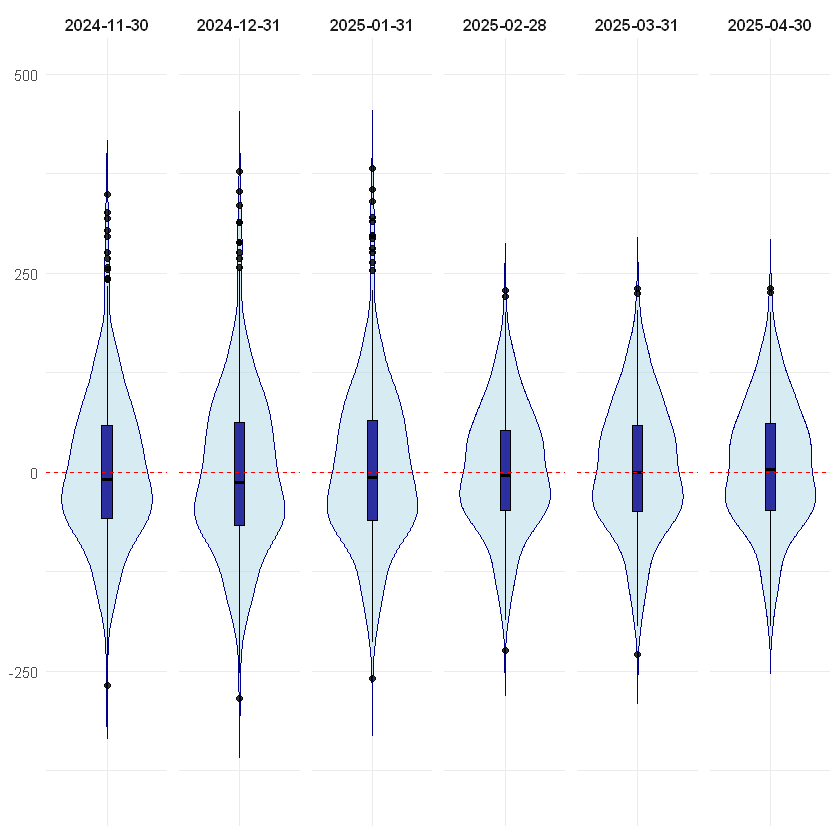

In [13]:
library(readxl)
library(ggplot2)
library(dplyr)

# Load the data
file_path <- "Nov_to_Apr_violins.xlsx"
data <- read_excel(file_path)

# Prepare data: select and filter
selected_data <- data %>%
  select(Month_End, PnL_Distribution) %>%
  filter(!is.na(Month_End) & !is.na(PnL_Distribution))

# Convert Month_End to Date
selected_data$Month_End <- as.Date(selected_data$Month_End)

# Order Month_End factor chronologically
selected_data$Month_End <- factor(selected_data$Month_End, levels = sort(unique(selected_data$Month_End)))

# Create combined plot with violin and boxplot layers, faceted by Month_End
combined_plot <- ggplot(selected_data, aes(x = factor(1), y = PnL_Distribution)) +
  geom_violin(trim = FALSE, fill = "lightblue", color = "darkblue", alpha = 0.5) +
  geom_boxplot(width = 0.1, fill = "darkblue", color = "black", alpha = 0.8) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  facet_wrap(~ Month_End, nrow = 1) +
  scale_y_continuous(limits = c(-400, 500)) +
  labs(x = NULL, y = NULL) +
  theme_minimal() +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(),
        strip.text = element_text(size = 10, face = "bold"),
        panel.spacing = unit(0.5, "lines"))

# Print the plot
print(combined_plot)
